In [1]:
import numpy as np

# ============================================================================
# Constants for Argon
# ============================================================================
sigma = 3.405e-10
epsilon_kB = 119.8
k_B = 1.380649e-23
epsilon = epsilon_kB * k_B
N_A = 6.02214076e23
R = 8.314462618  # J K^-1 mol^-1

# Reduced parameters used in simulation
T_star = 0.6995
N = 256

# Experimental values
U_exp = -5.97   # kJ/mol
P_exp = 0.689   # bar
Cv_exp = 6.9    # J K^-1 mol^-1 (configurational)

def p_star_to_bar(p_star):
    return p_star * epsilon / (sigma**3) / 1e5

def u_star_to_kJmol(u_star_per_particle):
    return u_star_per_particle * epsilon * N_A / 1000

# Load simulation trajectory data
# lets select only rows with 4 columns, which correspond to the main simulation data

clean_data = []

with open("log.dat") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 4:
            try:
                row = [float(x) for x in parts]
                clean_data.append(row)
            except:
                pass

data = np.array(clean_data)

steps = data[:, 0]
acc_ratio = data[:, 1]
energy_col = data[:, 2]      # U/N in reduced units
pressure_col = data[:, 3]    # p* in reduced units

# Averages from trajectory
U_star_mean = np.mean(energy_col)
P_star_mean = np.mean(pressure_col)
acc_mean = np.mean(acc_ratio)

# Convert to physical units
U_physical = u_star_to_kJmol(U_star_mean)
P_physical = p_star_to_bar(P_star_mean)

# Configurational heat capacity from fluctuations of U/N
Cv_config = R * N * (np.mean(energy_col**2) - np.mean(energy_col)**2) / (T_star**2)

print("=" * 60)
print("SIMULATION RESULTS")
print("=" * 60)

print("\nReduced units:")
print(f"  <acc>          = {acc_mean:.4f}")
print(f"  <U>/N          = {U_star_mean:.6f}")
print(f"  <p*>           = {P_star_mean:.6f}")

print("\nPhysical units:")
print(f"  <U>            = {U_physical:.3f} kJ/mol")
print(f"  <p>            = {P_physical:.4f} bar")
print(f"  Cv'            = {Cv_config:.3f} J K^-1 mol^-1")

print("\nExperimental values:")
print(f"  U_exp          = {U_exp:.2f} kJ/mol")
print(f"  P_exp          = {P_exp:.3f} bar")
print(f"  Cv'_exp        = {Cv_exp:.2f} J K^-1 mol^-1")

print("\nRelative differences:")
print(f"  ΔU             = {(U_physical - U_exp)/abs(U_exp)*100:.2f}%")
print(f"  ΔP             = {(P_physical - P_exp)/P_exp*100:.2f}%")
print(f"  ΔCv'           = {(Cv_config - Cv_exp)/Cv_exp*100:.2f}%")

SIMULATION RESULTS

Reduced units:
  <acc>          = 0.3237
  <U>/N          = -6.104896
  <p*>           = 0.044804

Physical units:
  <U>            = -6.081 kJ/mol
  <p>            = 18.7719 bar
  Cv'            = 8.612 J K^-1 mol^-1

Experimental values:
  U_exp          = -5.97 kJ/mol
  P_exp          = 0.689 bar
  Cv'_exp        = 6.90 J K^-1 mol^-1

Relative differences:
  ΔU             = -1.86%
  ΔP             = 2624.52%
  ΔCv'           = 24.82%


In [2]:
print("rows:", data.shape[0])
print("mean acc:", np.mean(acc_ratio))
print("mean U/N:", np.mean(energy_col))
print("mean p* :", np.mean(pressure_col))
print("std p*  :", np.std(pressure_col, ddof=1))
print("min/max p*:", np.min(pressure_col), np.max(pressure_col))

rows: 50
mean acc: 0.32370308000000003
mean U/N: -6.104896200000001
mean p* : 0.044804364399999984
std p*  : 0.24997806556106636
min/max p*: -0.521758 0.556167


In Metropolis MC, the sequence

$$A_1, A_2, \dots, A_M$$

is correlated, not independent.

So even if you have many samples, the effective number of useful samples is smaller.

That is why the variance of the mean is not simply

$$\mathrm{Var}(\bar A)=\frac{\mathrm{Var}(A)}{M}$$

but instead

$$\mathrm{Var}(\bar A)=\frac{2\tau_A}{M}\mathrm{Var}(A)$$

or equivalently with the statistical inefficiency s,

$$\mathrm{Var}(\bar A)=\frac{s}{M}\mathrm{Var}(A), \qquad s=2\tau_A$$

So the goal is:
	•	estimate s
	•	use it to get proper error bars for $\langle U\rangle$ and $\langle p\rangle$

Part (a): demonstrate equation (4) numerically

Equation (4) is for an uncorrelated sample:

$$\mathrm{Var}(A^{(n)})=\frac{1}{n}\mathrm{Var}(A)$$

where $A^{(n)}$ is the mean of a block of size n.

This is easy to verify with random independent numbers.

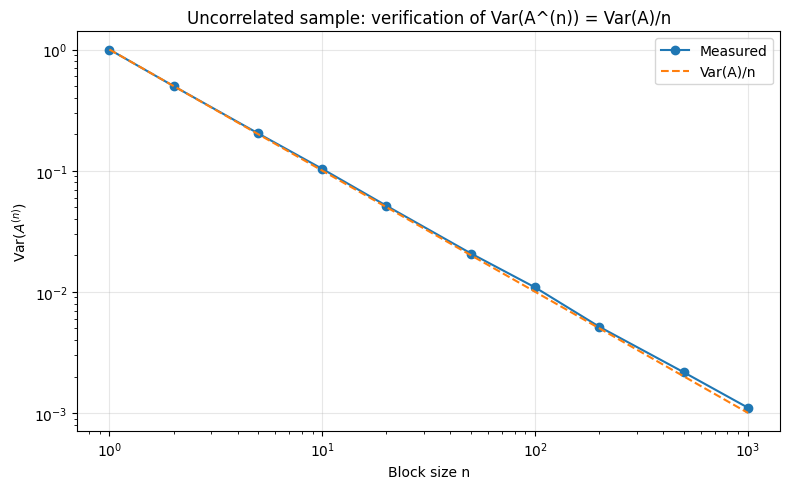

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

M = 100000
A = np.random.normal(loc=0.0, scale=1.0, size=M)

var_A = np.var(A)

block_sizes = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000])
var_block_means = []

for n in block_sizes:
    nb = M // n
    trimmed = A[:nb * n]
    blocks = trimmed.reshape(nb, n)
    block_means = blocks.mean(axis=1)
    var_block_means.append(np.var(block_means, ddof=1))

var_block_means = np.array(var_block_means)

plt.figure(figsize=(8, 5))
plt.loglog(block_sizes, var_block_means, 'o-', label='Measured')
plt.loglog(block_sizes, var_A / block_sizes, '--', label=r'Var(A)/n')
plt.xlabel('Block size n')
plt.ylabel(r'Var($A^{(n)}$)')
plt.title('Uncorrelated sample: verification of Var(A^(n)) = Var(A)/n')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("part_a_uncorrelated_demo.png", dpi=150)

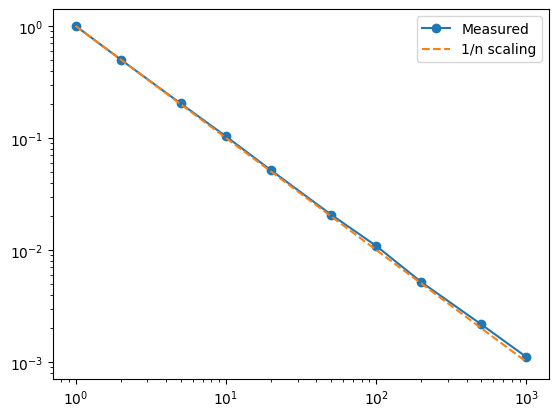

In [4]:
plt.loglog(block_sizes, var_block_means, 'o-', label='Measured')
plt.loglog(block_sizes, var_A / block_sizes, '--', label='1/n scaling')
plt.legend()

For independent samples, averaging over blocks of size n reduces the variance by a factor n. The numerical experiment confirms that the variance of the block means follows 1/n scaling.


Part (b): implement block means and error bars

Now we do this for MC outputs.

instantaneous values are:
	•	U[i]
	•	P[i]

from log.dat.

Core idea:

For each block size n:
	1.	split the data into blocks of size n
	2.	compute block means
	3.	compute variance of block means
	4.	estimate

$$s(n)=\frac{n\,\mathrm{Var}(A^{(n)})}{\mathrm{Var}(A)}$$

As n becomes large enough, s(n) reaches a plateau.

Then:

$$\mathrm{Var}(\bar A)=\frac{s}{M}\mathrm{Var}(A)$$

and the standard error is:

$$\sigma_{\bar A}=\sqrt{\frac{s}{M}\mathrm{Var}(A)}$$


In [5]:
import numpy as np
import glob

files = sorted(glob.glob("log_disp_*.dat"))

disps = []
acceptances = []
errors = []

for file in files:
    disp = float(file.split("_")[-1].replace(".dat",""))
    
    data = np.loadtxt(file)
    
    acc = np.mean(data[:,1])
    U = data[:,2]
    
    # naive error (you can replace with block method)
    err = np.std(U, ddof=1)/np.sqrt(len(U))
    
    disps.append(disp)
    acceptances.append(acc)
    errors.append(err)

print(disps, acceptances, errors)

[0.05, 0.1, 0.15, 0.2, 0.25] [np.float64(0.83885152), np.float64(0.67749216), np.float64(0.53810164), np.float64(0.41749998), np.float64(0.32370308000000003)] [np.float64(0.015293650075019465), np.float64(0.011550564797958445), np.float64(0.01341034585793326), np.float64(0.00854573582692991), np.float64(0.006356394054711806)]


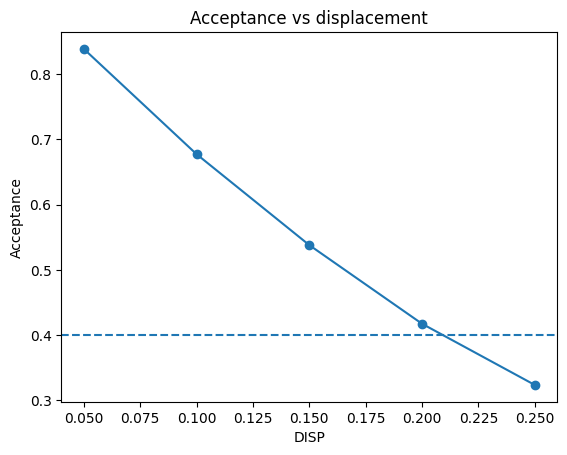

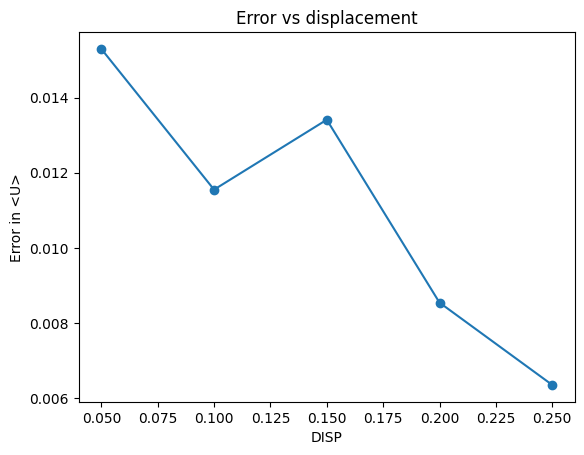

In [7]:
import matplotlib.pyplot as plt

plt.plot(disps, acceptances, 'o-')
plt.axhline(0.4, linestyle='--')
plt.xlabel("DISP")
plt.ylabel("Acceptance")
plt.title("Acceptance vs displacement")
plt.show()

plt.plot(disps, errors, 'o-')
plt.xlabel("DISP")
plt.ylabel("Error in <U>")
plt.title("Error vs displacement")
plt.show()